In [1]:
import pandas as pd
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = pd.read_csv("horse_colic_normalized.csv")

df_reduced = pd.read_csv(
    "horse_colic_reduced_encoded.csv",
    delimiter=","
)

target_col = "outcome"

data = data.dropna(subset=[target_col])
df_reduced = df_reduced.dropna(subset=[target_col])

In [2]:
X = data.drop(columns=[target_col])
y = data[target_col]

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_estimator = DecisionTreeClassifier(random_state=42)

bagging_model = BaggingClassifier(
    estimator=base_estimator,
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred = bagging_model.predict(X_test)


X_reduced = df_reduced.drop(columns=[target_col])
y_reduced = df_reduced[target_col]

X_reduced = X_reduced.fillna(X_reduced.median())

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y_reduced,
    test_size=0.2,
    random_state=42,
    stratify=y_reduced
)

base_estimator_reduced = DecisionTreeClassifier(random_state=42)

bagging_model_reduced = BaggingClassifier(
    estimator=base_estimator_reduced,
    n_estimators=10,
    random_state=42
)

bagging_model_reduced.fit(X_train_reduced, y_train_reduced)

y_pred_reduced = bagging_model_reduced.predict(X_test_reduced)

In [3]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

accuracy_reduced = accuracy_score(y_test_reduced, y_pred_reduced)
print(f"Accuracy reduced: {accuracy_reduced:.2f}")

Accuracy: 0.70
Accuracy reduced: 0.68


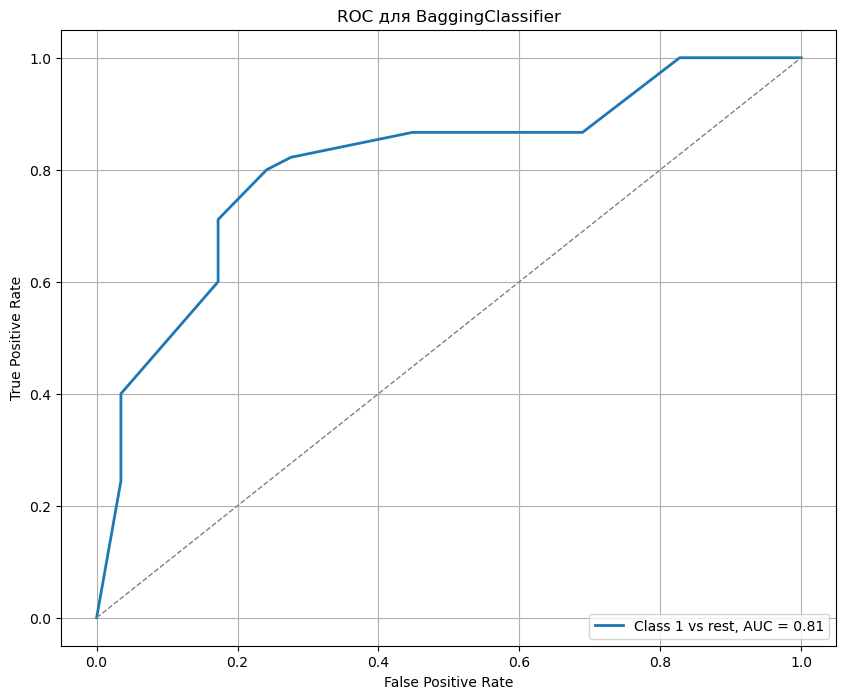

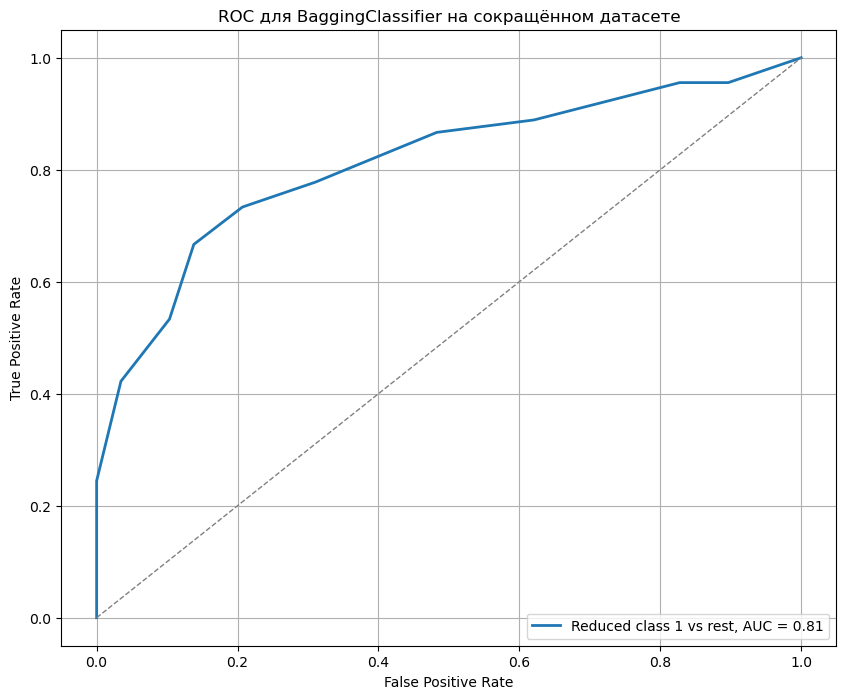

In [4]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

positive_class = 1

y_test_binary = (y_test == positive_class).astype(int)

class_index = list(bagging_model.classes_).index(positive_class)
y_prob = bagging_model.predict_proba(X_test)[:, class_index]

fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, lw=2, label=f'Class {positive_class} vs rest, AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC для BaggingClassifier')
plt.legend(loc='lower right')
plt.grid()
plt.show()


y_test_reduced_binary = (y_test_reduced == positive_class).astype(int)

class_index_reduced = list(bagging_model_reduced.classes_).index(positive_class)
y_prob_reduced = bagging_model_reduced.predict_proba(X_test_reduced)[:, class_index_reduced]

fpr_reduced, tpr_reduced, _ = roc_curve(
    y_test_reduced_binary,
    y_prob_reduced
)

roc_auc_reduced = auc(fpr_reduced, tpr_reduced)

plt.figure(figsize=(10, 8))
plt.plot(
    fpr_reduced,
    tpr_reduced,
    lw=2,
    label=f'Reduced class {positive_class} vs rest, AUC = {roc_auc_reduced:.2f}'
)

plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC для BaggingClassifier на сокращённом датасете')
plt.legend(loc='lower right')
plt.grid()
plt.show()

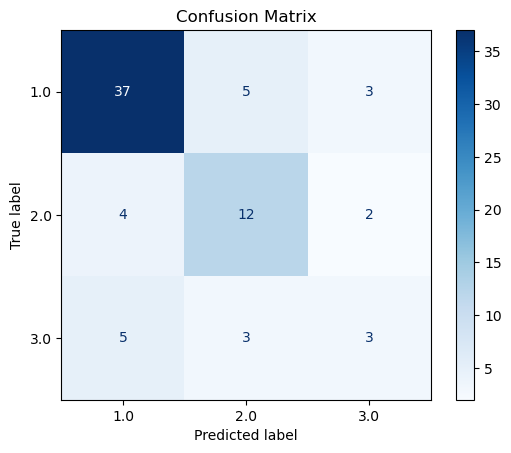

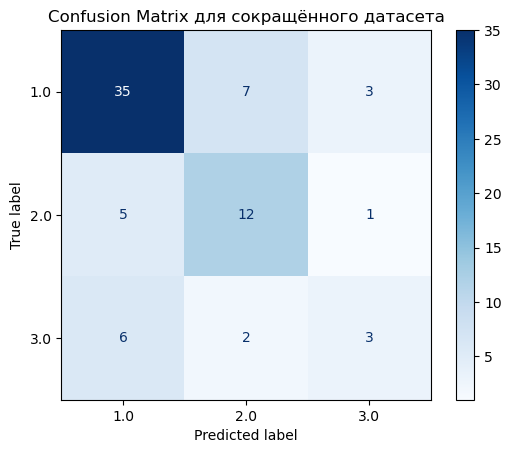

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=bagging_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

conf_matrix_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)

disp_reduced = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix_reduced,
    display_labels=bagging_model_reduced.classes_
)

disp_reduced.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix для сокращённого датасета")
plt.show()